<big><big>001: data pre-processing walkthrough</big></big>
<a id='index'></a><br>

- [part 0: pre-processing for a single object](#steps)
    - alert processor
    - photometry processor
    - data preprocessor
    - [images](#images)
    - <s>[alert selection](#alert)</s>
    - [spectra](#spectra)
- [part 1: pre-processing a dataset](#transient)

In [14]:
import pandas as pd
import numpy as np
import os
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from src_dataloader.data_preprocessor import AlertProcessor, PhotometryProcessor, DataPreprocessor, SpectraProcessor
from src_dataloader.data_preprocessor import DataSorter
from src_dataloader.transient_dataset import TransientDataset
import src_dataloader.plot_data as plot_data

In [136]:
SEDM_dataset = pd.read_csv('/AppleCider/SEDM_dataset.csv')
SEDM_dataset

,obj_id,type
0,ZTF18aatfxtd,SN Ia
1,ZTF18aawppyt,SN Ia
2,ZTF18aakpnyt,AGN
3,ZTF18aclgopa,AGN
4,ZTF18adjoimi,AGN
...,...,...
7493,ZTF18aajlxao,AGN
7494,ZTF18abmwqkr,AGN
7495,ZTF19aadzgnt,AGN
7496,ZTF19aaesrrd,AGN


<big>part 0: pre-processing for a single object</big>

<a id='steps'></a>


In [137]:
obj_SN = 'ZTF20aambbfn'  # other cute SN Ia: ZTF20aarasxl, ZTF20aafjjqj, ZTF22abtbijr
data_dir = 'AppleCider_Data/SEDM_folder'

# loading data from folder
# change column names, add object id, object type to make photo_df
photo_df = PhotometryProcessor.process_csv(obj_SN, SEDM_dataset, data_dir)
metadata_df, images = AlertProcessor.get_process_alerts(obj_SN, data_dir)

In [138]:
photo_df[:2]

,obj_id,jd,mjd,mag,magerr,snr,limiting_mag,filter,type
0,ZTF20aambbfn,2.458887e+06,58886.242130,19.611099,0.285659,6.18730,19.445999,ztfg,SN Ia
1,ZTF20aambbfn,2.458885e+06,58884.489363,19.048901,0.134265,6.29451,19.866400,ztfr,SN Ia


In [139]:
metadata_df[:2]

,jd,fid,pid,diffmaglim,pdiffimfilename,programpi,programid,candid,isdiffpos,tblid,...,clrmed,clrrms,neargaia,neargaiabright,maggaia,maggaiabright,exptime,drb,drbversion,obj_id
0,2.458885e+06,2,1130489363715,19.866436,ztf_20200205489340_000752_zr_c10_o_q2_scimrefd...,Kulkarni,3,1130489363715015004,t,4,...,0.742,0.327286,0.976307,-999.0,18.066233,-999.0,30.0,0.996355,d6_m7,ZTF20aambbfn
1,2.458887e+06,1,1132243023715,19.475851,ztf_20200207243021_000752_zg_c10_o_q2_scimrefd...,Kulkarni,1,1132243023715015001,t,1,...,0.601,0.294263,1.226615,-999.0,18.066233,-999.0,30.0,0.976252,d6_m7,ZTF20aambbfn


In [140]:
# sort by date (JD)
# add metadata missing from photometry
photo_df, metadata_df = photo_df.sort_values(by='jd'), metadata_df.sort_values(by='jd')
photo_df = PhotometryProcessor.add_metadata_to_photometry(photo_df, metadata_df)
photo_df[:2]

,obj_id,jd,mjd,mag,magerr,snr,limiting_mag,filter,type
0,ZTF20aambbfn,2.458885e+06,58884.489363,19.048901,0.134265,6.29451,19.866400,ztfr,SN Ia
1,ZTF20aambbfn,2.458887e+06,58886.242130,19.611099,0.285659,6.18730,19.445999,ztfg,SN Ia


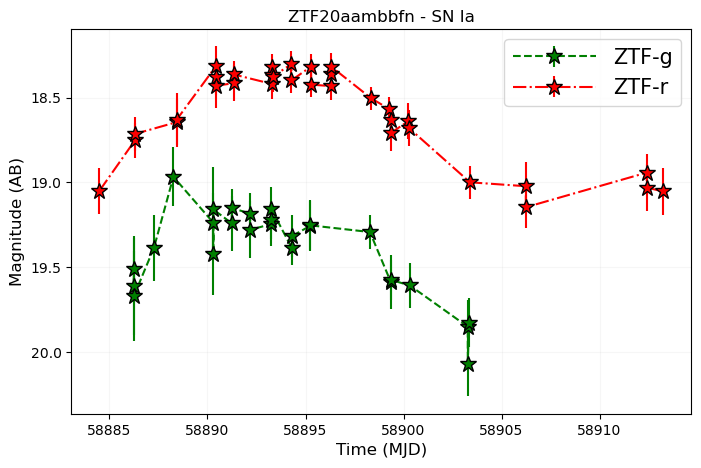

In [141]:
plot_data.plot_photometry_magnitude(photo_df)

<a id='images'></a>

55
Selected index: [ 3 20 37 54]
Image number: 3


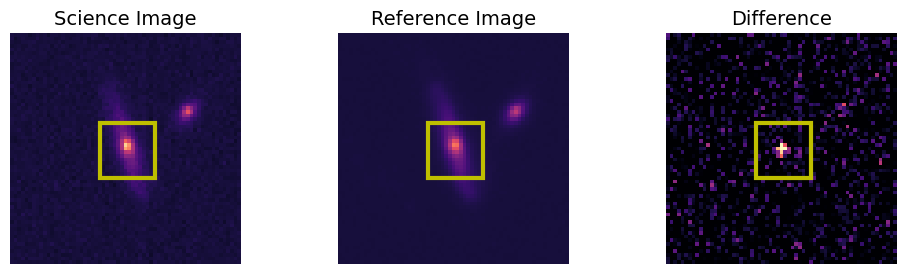

Image number: 20


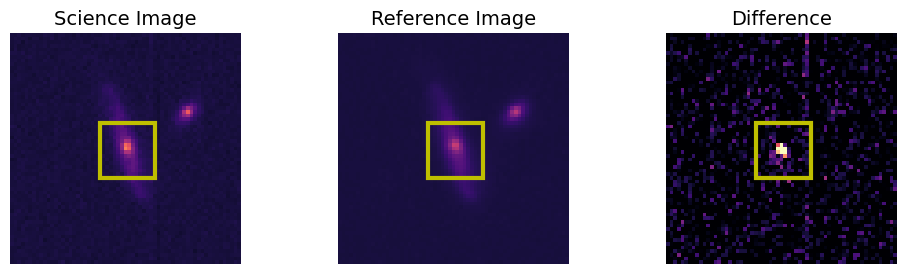

Image number: 37


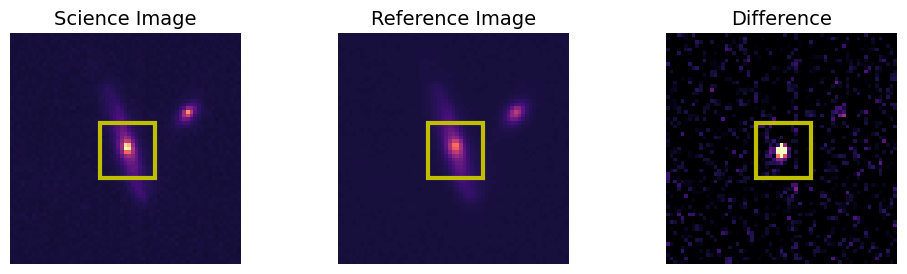

Image number: 54


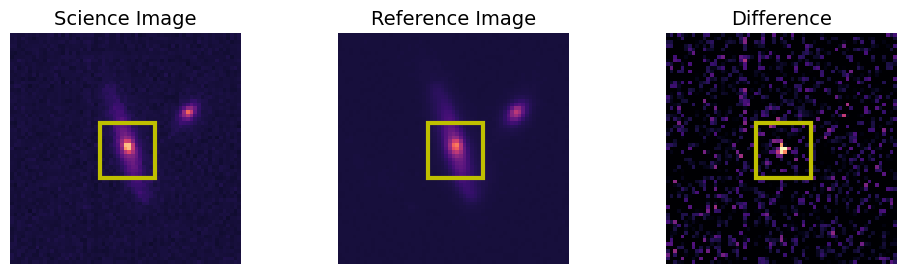

In [142]:
print(len(images))

n = 3
selected_index = np.round(np.linspace(3, len(images) - 1, n)).astype(int)
print('Selected index:', selected_index)
for i in selected_index:
    print('Image number:', i)
    plot_data.plot_image(images[i], vmin_set=0.004, vmax_set=0.099)

In [129]:
photo_df_process = DataPreprocessor.convert_photometry(photo_df)
photo_df_process[:1]

,obj_id,mjd,flux,flux_error,filter,type,jd
0,ZTF20aambbfn,0.0,87.184596,10.781477,ztfr,SN Ia,2.458885e+06


In [130]:
start_index = PhotometryProcessor.get_first_valid_index(photo_df_process)
print('Start index:', start_index)

Start index: 0


<a id='alert'></a>

In [ ]:
#for i in selected_index:
#    print('Photometry at index:', i)
#    photo_ready = DataPreprocessor.cut_photometry(photo_df_process, metadata_df, i)
#    plot_data.plot_photometry_magnitude(photo_ready)

<a id='spectra'></a>

In [152]:
# spectra steps...

<a id='spectra'></a>

In [ ]:
SpectraProcessor.get_spectra_df(obj_SN, data_dir)

In [ ]:
plot_data.plot_spectra(obj_SN, SEDM_dataset, data_dir)

In [ ]:
# preprocess spectra
spectra = SpectraProcessor.read_spectra_csv(obj_SN, data_dir)
SpectraProcessor.preprocess_spectra(spectra)

***

<big><big>part 1: pre-processing the dataset</big></big>

<a id='transient'></a>
<i><small>[back to index](#index)</small></i>

In [143]:
TEST_DATA_PATH = 'AppleCider_Data/sedm_data_test_2-7'
TRAIN_DATA_PATH = 'AppleCider_Data/sedm_data_train_2-7'

CLASSES = ['SN Ia', 'SN Ia-91T', 'SN II', 'SN IIP', 'Cataclysmic', 'AGN', 'SN IIn', 'SN Ic', 'SN Ib', 'SN IIb', 'Tidal Disruption Event',
           'Stellar variable']

In [148]:
test_df, train_df = DataSorter.sample_objects_from_df(SEDM_dataset, 'type', CLASSES, data_dir, n_test=1000, n_train=6000, sedm_spec_only=False, downsample_SNIa=False)

In [149]:
test_df

,obj_id,type
0,ZTF24aailzom,SN Ia
1,ZTF19aawupxb,SN Ia
2,ZTF23aaalcjc,SN Ia
3,ZTF21acefbte,SN Ia
4,ZTF19acuyvtl,SN Ia
...,...,...
1005,ZTF21aalimya,SN IIb
1006,ZTF21aaxtrlt,SN Ia-91T
1007,ZTF21abahiow,SN Ib
1008,ZTF21abrfvax,SN Ic


In [150]:
train_df

,obj_id,type
0,ZTF22abtlaew,SN Ia
1,ZTF20acoaqpm,SN Ia
2,ZTF21aarigsr,SN Ia
3,ZTF20aafwbcs,SN Ia
4,ZTF19abirbpd,SN Ia
...,...,...
5995,ZTF20abaszgh,SN Ib
5996,ZTF20abpvhlg,SN IIP
5997,ZTF19acftude,SN IIn
5998,ZTF22aabnvrz,SN Ia


In [151]:
dataset_test = TransientDataset(TEST_DATA_PATH, base_path=data_dir)
dataset_test.preprocess_data(test_df, data_dir)

dataset_test.preprocess_and_save()

Loading data:   0%|          | 0/1010 [00:00<?, ?it/s]

Processing Objects:   0%|          | 0/4829 [00:00<?, ?it/s]

In [ ]:
dataset_train = TransientDataset(TRAIN_DATA_PATH, base_path=data_dir)
dataset_train.preprocess_data(train_df, data_dir)

dataset_train.preprocess_and_save()

Loading data:   0%|          | 0/6000 [00:00<?, ?it/s]

In [ ]:
# make dataframe of object IDs with associated alert file names, and clasification 
data_test, data_train = DataSorter.create_df_of_object_alerts_in_dataset(test_df, train_df, TEST_DATA_PATH, TRAIN_DATA_PATH

In [ ]:
data_test

In [ ]:
data_train.to_csv('data_train_2-7.csv', index=False)
data_test.to_csv('data_test_2-7.csv', index=False)

In [ ]:
# example alert